# Tuned Lens: Learning Per-Layer Transforms

**Survey Reference:** Section 8.2 — Tuned Lens

**Prerequisite:** [01_logit_lens.ipynb](./01_logit_lens.ipynb)

## Overview

The logit lens projects intermediate hidden states through the unembedding matrix to see what a model "believes" at each layer. However, it **systematically underperforms** because intermediate layers may encode information in a **rotated or shifted basis** that doesn't align with the unembedding matrix.

The **Tuned Lens** ([Belrose et al., 2023](https://arxiv.org/abs/2303.08112)) fixes this by learning a per-layer affine translator:

$$\text{TunedLens}(h_\ell) = \text{softmax}\big((h_\ell + A_\ell h_\ell + b_\ell) \cdot W_U\big)$$

The translator is added **residually** (initialized to zero), so the tuned lens starts as the logit lens and learns corrections.

## Learning Objectives

1. Understand why learned transforms help (representation drift)
2. Train a tuned lens from scratch (pedagogical)
3. Load and use pre-trained tuned lens weights
4. Compare logit lens vs tuned lens predictions
5. Analyze what the learned transforms reveal

In [1]:
%pip install torch transformers matplotlib numpy tuned-lens datasets --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "openai-community/gpt2-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()
print(f"Loaded {model_name}: {model.config.n_layer} layers, d={model.config.n_embd}")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Using device: cuda
Loaded openai-community/gpt2-large: 36 layers, d=1280


## 1. The Tuned Lens Architecture

The tuned lens learns a per-layer affine transform. Key design choices:

1. **Residual parameterization:** $h' = h + A_\ell h + b_\ell$ (not $h' = A_\ell h + b_\ell$)
   - Initialized to zero → starts as identity (same as logit lens)
   - Weight decay regularizes toward identity, not zero
   
2. **Trained on KL divergence from final layer** (not ground truth)
   - Reports what the model *believes*, not what is *true*
   
3. **One translator per layer** (no translator for final layer output)

In [2]:
class TunedLensFromScratch(nn.Module):
    """
    Tuned Lens: learns per-layer affine translators (residual parameterization).
    
    Each translator is initialized to zero, so the lens starts as the logit lens.
    Output: h' = h + translator(h), then apply ln_f and unembed.
    """
    
    def __init__(self, n_layers: int, hidden_size: int):
        super().__init__()
        self.n_layers = n_layers
        self.hidden_size = hidden_size
        
        # Per-layer translators (residual: output = h + translator(h))
        self.translators = nn.ModuleList([
            nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)
        ])
        
        # Initialize to zero (starts as logit lens)
        for t in self.translators:
            nn.init.zeros_(t.weight)
            nn.init.zeros_(t.bias)
    
    def forward(self, h: torch.Tensor, layer_idx: int, model) -> torch.Tensor:
        """Apply tuned lens at a specific layer."""
        # Residual connection: h + translator(h)
        h_translated = h + self.translators[layer_idx](h)
        # Apply final layer norm and unembed
        return model.transformer.ln_f(h_translated) @ model.lm_head.weight.T

## 2. Training the Tuned Lens

The tuned lens is trained to minimize KL divergence between each layer's prediction and the final layer's prediction. This teaches the translator to correct for representation drift.

In [3]:
from datasets import load_dataset

def train_tuned_lens(model, tokenizer, lens, train_texts, n_epochs=3, lr=1e-3):
    """
    Train tuned lens using KL divergence (same as official implementation).
    
    Each layer's translator learns to match the final layer's probability distribution.
    KL(final || layer) measures how well layer predictions match final predictions.
    """
    optimizer = torch.optim.Adam(lens.parameters(), lr=lr)
    history = []
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        n_samples = 0
        
        for text in tqdm(train_texts, desc=f"Epoch {epoch+1}", leave=False):
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
            if inputs.input_ids.shape[1] < 2:
                continue
            
            with torch.no_grad():
                outputs = model(**inputs, output_hidden_states=True)
                # Target: final layer's log probabilities
                final_logits = outputs.logits.float()
                final_log_probs = F.log_softmax(final_logits, dim=-1)
                final_probs = final_log_probs.exp()
            
            hidden_states = outputs.hidden_states
            
            # Train each layer's translator
            loss = 0.0
            for layer_idx in range(len(hidden_states) - 1):
                h = hidden_states[layer_idx]
                # Get this layer's prediction via tuned lens
                layer_logits = lens(h, layer_idx, model).float()
                layer_log_probs = F.log_softmax(layer_logits, dim=-1)
                
                # KL(final || layer) = sum(p_final * (log_p_final - log_p_layer))
                kl = (final_probs * (final_log_probs - layer_log_probs)).sum(dim=-1).mean()
                loss = loss + kl
            
            loss = loss / (len(hidden_states) - 1)  # Average over layers
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(lens.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            n_samples += 1
        
        avg_loss = total_loss / max(n_samples, 1)
        history.append(avg_loss)
        print(f"  Epoch {epoch+1}: avg KL = {avg_loss:.4f} nats")
    
    return history

# Load training data
print("Loading WikiText-2 training data...")
wikitext = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
train_texts = [t for t in wikitext["text"] if len(t.strip()) > 50][:500]
print(f"Loaded {len(train_texts)} training samples")

Loading WikiText-2 training data...
Loaded 500 training samples


## 3. Loading Pre-Trained Tuned Lens

The [tuned-lens](https://github.com/AlignmentResearch/tuned-lens) library provides pre-trained weights for many models. These are trained on much larger corpora and perform better than our small demo.

In [4]:
from tuned_lens import TunedLens

# Load pre-trained tuned lens (trained on large corpus)
tuned_lens = TunedLens.from_model_and_pretrained(model, lens_resource_id="gpt2-large")
tuned_lens = tuned_lens.to(device)
tuned_lens.eval()
print(f"Loaded pre-trained tuned lens: {len(tuned_lens)} layer translators")

Loaded pre-trained tuned lens: 36 layer translators


In [5]:
def get_hidden_states(model, tokenizer, text):
    """Get all hidden states for a text."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    tokens = [tokenizer.decode(t) for t in inputs.input_ids[0]]
    return outputs.hidden_states, tokens

def logit_lens(h, model):
    """Apply logit lens: ln_f then unembed."""
    return model.transformer.ln_f(h) @ model.lm_head.weight.T

## 4. Comparing Logit Lens vs Tuned Lens

Let's compare predictions from both lenses across layers.

In [6]:
text = "The Eiffel Tower is located in the city of"
hidden_states, tokens = get_hidden_states(model, tokenizer, text)

print(f'"{text}" → next token\n')
print(f'{"Layer":>8s}  {"LL Pred":<14s} {"LL Prob":>7s}  {"TL Pred":<14s} {"TL Prob":>7s}')
print("-" * 62)

with torch.no_grad():
    for i, h in enumerate(hidden_states[:-1]):  # Exclude final
        # Logit lens
        ll_logits = logit_lens(h, model)[0, -1]
        ll_probs = F.softmax(ll_logits, dim=-1)
        ll_top = ll_logits.argmax()
        
        # Tuned lens (pre-trained)
        tl_logits = tuned_lens(h, i)[0, -1]
        tl_probs = F.softmax(tl_logits, dim=-1)
        tl_top = tl_logits.argmax()
        
        label = "embed" if i == 0 else f"layer {i-1}"
        ll_word = repr(tokenizer.decode(ll_top))
        tl_word = repr(tokenizer.decode(tl_top))
        print(f"{label:>8s}  {ll_word:<14s} {ll_probs[ll_top].item():>7.3f}  {tl_word:<14s} {tl_probs[tl_top].item():>7.3f}")

"The Eiffel Tower is located in the city of" → next token

   Layer  LL Pred        LL Prob  TL Pred        TL Prob
--------------------------------------------------------------
   embed  ' of'            1.000  ' the'           0.203
 layer 0  ' the'           0.140  ' the'           0.260
 layer 1  ' the'           0.043  ' the'           0.213
 layer 2  ' the'           0.028  ' the'           0.223
 layer 3  ' the'           0.022  ' the'           0.163
 layer 4  ' the'           0.021  ' the'           0.169
 layer 5  ' the'           0.020  ' the'           0.130
 layer 6  ' the'           0.021  ' the'           0.107
 layer 7  ' the'           0.017  ' the'           0.078
 layer 8  ' West'          0.015  ' the'           0.041
 layer 9  ' San'           0.030  ' South'         0.032
layer 10  ' San'           0.054  ' the'           0.047
layer 11  ' San'           0.041  ' San'           0.033
layer 12  ' San'           0.044  ' San'           0.030
layer 13  ' San'       

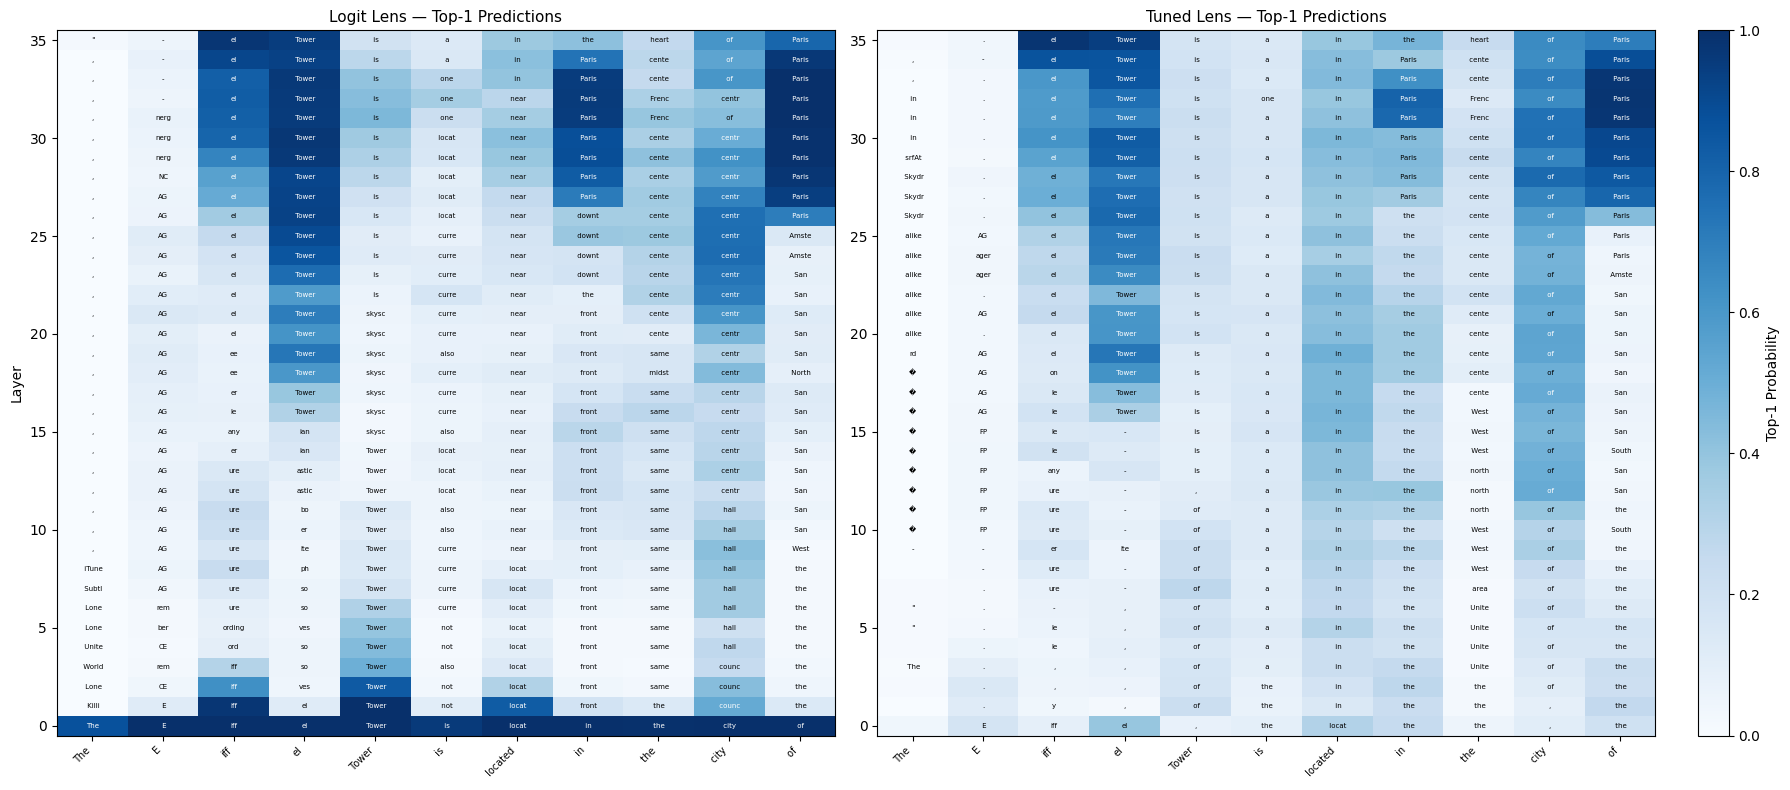

In [7]:
def plot_lens_heatmap(logits, tokens, title, ax):
    """Plot top-1 probability heatmap."""
    probs = F.softmax(logits, dim=-1)
    top_probs, top_ids = probs.max(dim=-1)
    n_layers, seq_len = top_probs.shape
    data = top_probs.cpu().numpy()
    
    im = ax.imshow(data, aspect="auto", cmap="Blues", vmin=0, vmax=1, origin="lower")
    
    # Add token labels
    words = [[tokenizer.decode(t.item())[:6] for t in layer] for layer in top_ids]
    for l in range(n_layers):
        for t in range(seq_len):
            ax.text(t, l, words[l][t], ha="center", va="center",
                    fontsize=5, color="white" if data[l, t] > 0.5 else "black")
    
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Layer")
    ax.set_title(title, fontsize=11)
    return im

# Compute logits for all layers
with torch.no_grad():
    ll_all = torch.stack([logit_lens(h, model)[0] for h in hidden_states[:-1]])
    tl_all = torch.stack([tuned_lens(h, i)[0] for i, h in enumerate(hidden_states[:-1])])

fig, axes = plt.subplots(1, 3, figsize=(18, 8), gridspec_kw={"width_ratios": [1, 1, 0.04]})
plot_lens_heatmap(ll_all, tokens, "Logit Lens — Top-1 Predictions", axes[0])
im = plot_lens_heatmap(tl_all, tokens, "Tuned Lens — Top-1 Predictions", axes[1])
axes[1].set_ylabel("")
fig.colorbar(im, cax=axes[2], label="Top-1 Probability")
plt.tight_layout()
plt.show()

## 5. KL Divergence from Final Layer

The tuned lens should have **lower KL divergence** from the final layer, meaning its predictions are closer to the model's actual output.

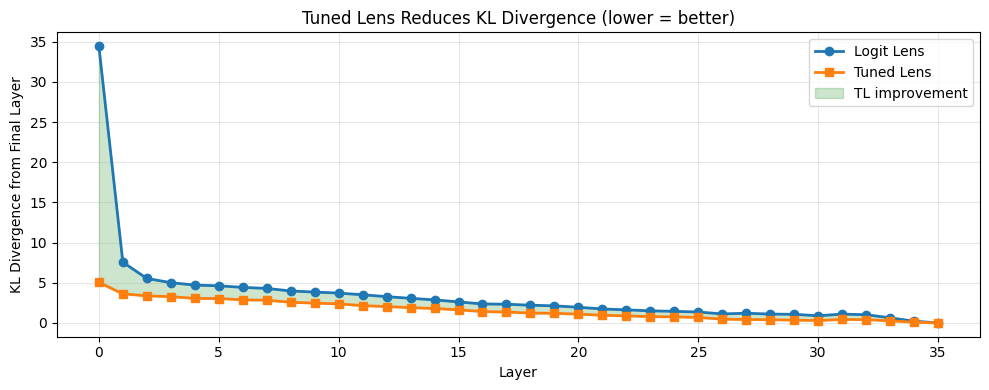


Mean KL reduction: 1.861
Logit Lens mean KL: 3.453
Tuned Lens mean KL: 1.592


In [8]:
def compute_kl_from_final(all_logits):
    """Compute KL(final || layer) for each layer."""
    with torch.no_grad():
        final_probs = F.softmax(all_logits[-1], dim=-1)
        final_log_probs = F.log_softmax(all_logits[-1], dim=-1)
        
        kl_values = []
        for layer_logits in all_logits:
            layer_log_probs = F.log_softmax(layer_logits, dim=-1)
            # KL(final || layer) = sum(final * (log_final - log_layer))
            kl = (final_probs * (final_log_probs - layer_log_probs)).sum(dim=-1).mean()
            kl_values.append(kl.item())
    return kl_values

ll_kl = compute_kl_from_final(ll_all)
tl_kl = compute_kl_from_final(tl_all)

plt.figure(figsize=(10, 4))
layers = range(len(ll_kl))
plt.plot(layers, ll_kl, 'o-', label='Logit Lens', linewidth=2)
plt.plot(layers, tl_kl, 's-', label='Tuned Lens', linewidth=2)
plt.fill_between(layers, tl_kl, ll_kl, alpha=0.2, color='green', label='TL improvement')
plt.xlabel("Layer")
plt.ylabel("KL Divergence from Final Layer")
plt.title("Tuned Lens Reduces KL Divergence (lower = better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMean KL reduction: {np.mean(ll_kl) - np.mean(tl_kl):.3f}")
print(f"Logit Lens mean KL: {np.mean(ll_kl):.3f}")
print(f"Tuned Lens mean KL: {np.mean(tl_kl):.3f}")

## 6. Training from Scratch (Demo)

Let's train our own tuned lens using **KL divergence** (same as the official implementation).

**Important:** This is a pedagogical demo only. The pre-trained lens was trained on millions of tokens; our demo uses ~300 samples. Don't expect our trained lens to outperform the pre-trained one — the goal is to understand the training process.

Training tuned lens from scratch (KL divergence)...


  Epoch 1: avg KL = 1.9009 nats


  Epoch 2: avg KL = 1.2915 nats


  Epoch 3: avg KL = 1.0582 nats


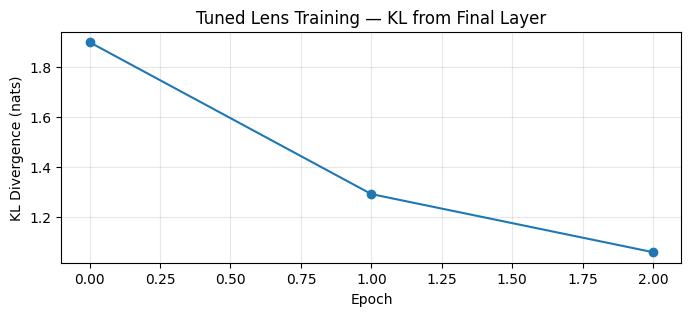

In [9]:
# Train our own tuned lens
my_lens = TunedLensFromScratch(model.config.n_layer, model.config.n_embd).to(device)
print("Training tuned lens from scratch (KL divergence)...")
history = train_tuned_lens(model, tokenizer, my_lens, train_texts[:100], n_epochs=3)

# Plot training curve
plt.figure(figsize=(8, 3))
plt.plot(history, 'o-')
plt.xlabel("Epoch")
plt.ylabel("KL Divergence (nats)")
plt.title("Tuned Lens Training — KL from Final Layer")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Compare all three lenses
# Note: Our trained lens won't beat the pre-trained one (trained on millions of tokens)
# This demo shows the training process works, not that we can improve over pre-trained quality

mid = model.config.n_layer // 2
h_mid = hidden_states[mid]

with torch.no_grad():
    ll_logits = logit_lens(h_mid, model)[0, -1]
    tl_logits = tuned_lens(h_mid, mid)[0, -1]
    my_logits = my_lens(h_mid, mid, model)[0, -1]

print(f"Predictions at layer {mid} for: '{text}'\n")
print(f"Logit Lens: {repr(tokenizer.decode(ll_logits.argmax()))}")
print(f"Pre-trained TL: {repr(tokenizer.decode(tl_logits.argmax()))}")
print(f"Our trained TL: {repr(tokenizer.decode(my_logits.argmax()))}")
print(f"\nThe pre-trained lens was trained on millions of tokens.")
print(f"Our lens was trained on ~100 samples — it demonstrates the")
print(f"training process but won't match pre-trained quality.")

Predictions at layer 18 for: 'The Eiffel Tower is located in the city of'

Logit Lens: ' North'
Pre-trained TL: ' San'
Our trained TL: ' Little'

The pre-trained lens was trained on millions of tokens.
Our lens was trained on ~100 samples — it demonstrates the
training process but won't match pre-trained quality.


## Key Takeaways

1. **The tuned lens** learns per-layer affine transforms that correct for representation drift
2. **Residual parameterization** ($h + Ah + b$) makes training stable and starts as logit lens
3. **KL divergence training** teaches the lens to match the final layer's beliefs
4. **Pre-trained lenses** (from the `tuned-lens` library) significantly outperform logit lens
5. **Lower KL divergence** = predictions closer to the model's actual output
6. The tuned lens reveals that models **do** form predictions early, but in a rotated basis

## References

- [Belrose et al. (2023). Eliciting Latent Predictions from Transformers with the Tuned Lens](https://arxiv.org/abs/2303.08112)
- [tuned-lens GitHub](https://github.com/AlignmentResearch/tuned-lens)